In [1]:
"""
Plasma Shadow Analysis
"""

'\nPlasma Shadow Analysis\n'

In [15]:
%matplotlib inline

import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import yaml
import os


In [16]:
os.makedirs('../plots/shadows/plasma', exist_ok=True)

with open('../config/params.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [17]:
rho_s = config['dark_matter']['rho_s']
r_s = config['dark_matter']['r_s']
C1 = config['wormhole']['C1']
Q = config['wormhole']['Q']


In [18]:
from src.dark_matter import DarkMatterProfile
from src.shape_function import ShapeFunction
from src.metric import ChargedWormholeMetric
from src.plasma import PlasmaProfile
from src.shadow_plasma import PlasmaShadow

sf = ShapeFunction(rho_s, r_s, C1, Q)
metric = ChargedWormholeMetric(sf)


In [24]:
plasma_densities = [0.0, 0.3, 0.5, 0.7]
shadow_images = []
labels = []
shadow_fractions = []

print("Generating plasma shadows...")
print("=" * 60)

# First, find the photon sphere radius for vacuum (rho=0)
test_plasma = PlasmaProfile('homogeneous', 0.0)
test_shadow = PlasmaShadow(metric, test_plasma, observer_inclination=17)
r_ph_vacuum = test_shadow.find_photon_sphere()
print(f"Photon sphere radius (vacuum): {r_ph_vacuum:.3f}")
print("=" * 60)

for rho in plasma_densities:
    print(f"\n  rho = {rho}")
    plasma = PlasmaProfile('homogeneous', rho)
    shadow = PlasmaShadow(metric, plasma, observer_inclination=17)
    
    # Calculate the expected shadow radius
    if rho < 1:
        r_crit = r_ph_vacuum / np.sqrt(1 - rho)
    else:
        r_crit = r_ph_vacuum * 10  # fallback
    
    # Auto-set bounds to show the full shadow
    alpha_max = max(50, r_crit * 1.5)
    beta_max = alpha_max
    
    print(f"    r_crit: {r_crit:.2f}, alpha_max: {alpha_max:.2f}")
    
    img = shadow.generate_shadow_image(N_pixels=300, alpha_max=alpha_max, beta_max=beta_max)
    shadow_images.append(img)
    labels.append(f'ρ = {rho}')
    
    dark_pixels = np.sum(img == 0)
    bright_pixels = np.sum(img == 1)
    total_pixels = img.size
    print(f"    Dark: {dark_pixels}, Bright: {bright_pixels}")
    print(f"    Shadow fraction: {dark_pixels/total_pixels*100:.1f}%")

Generating plasma shadows...
Photon sphere radius (vacuum): 20.000

  rho = 0.0
    r_crit: 20.00, alpha_max: 50.00


100%|██████████| 300/300 [00:00<00:00, 7922.50it/s]


    Dark: 11248, Bright: 78752
    Shadow fraction: 12.5%

  rho = 0.3
    r_crit: 23.90, alpha_max: 50.00


100%|██████████| 300/300 [00:00<00:00, 8154.31it/s]


    Dark: 16044, Bright: 73956
    Shadow fraction: 17.8%

  rho = 0.5
    r_crit: 28.28, alpha_max: 50.00


100%|██████████| 300/300 [00:00<00:00, 8946.19it/s]


    Dark: 22472, Bright: 67528
    Shadow fraction: 25.0%

  rho = 0.7
    r_crit: 36.51, alpha_max: 54.77


100%|██████████| 300/300 [00:00<00:00, 7599.94it/s]

    Dark: 31224, Bright: 58776
    Shadow fraction: 34.7%


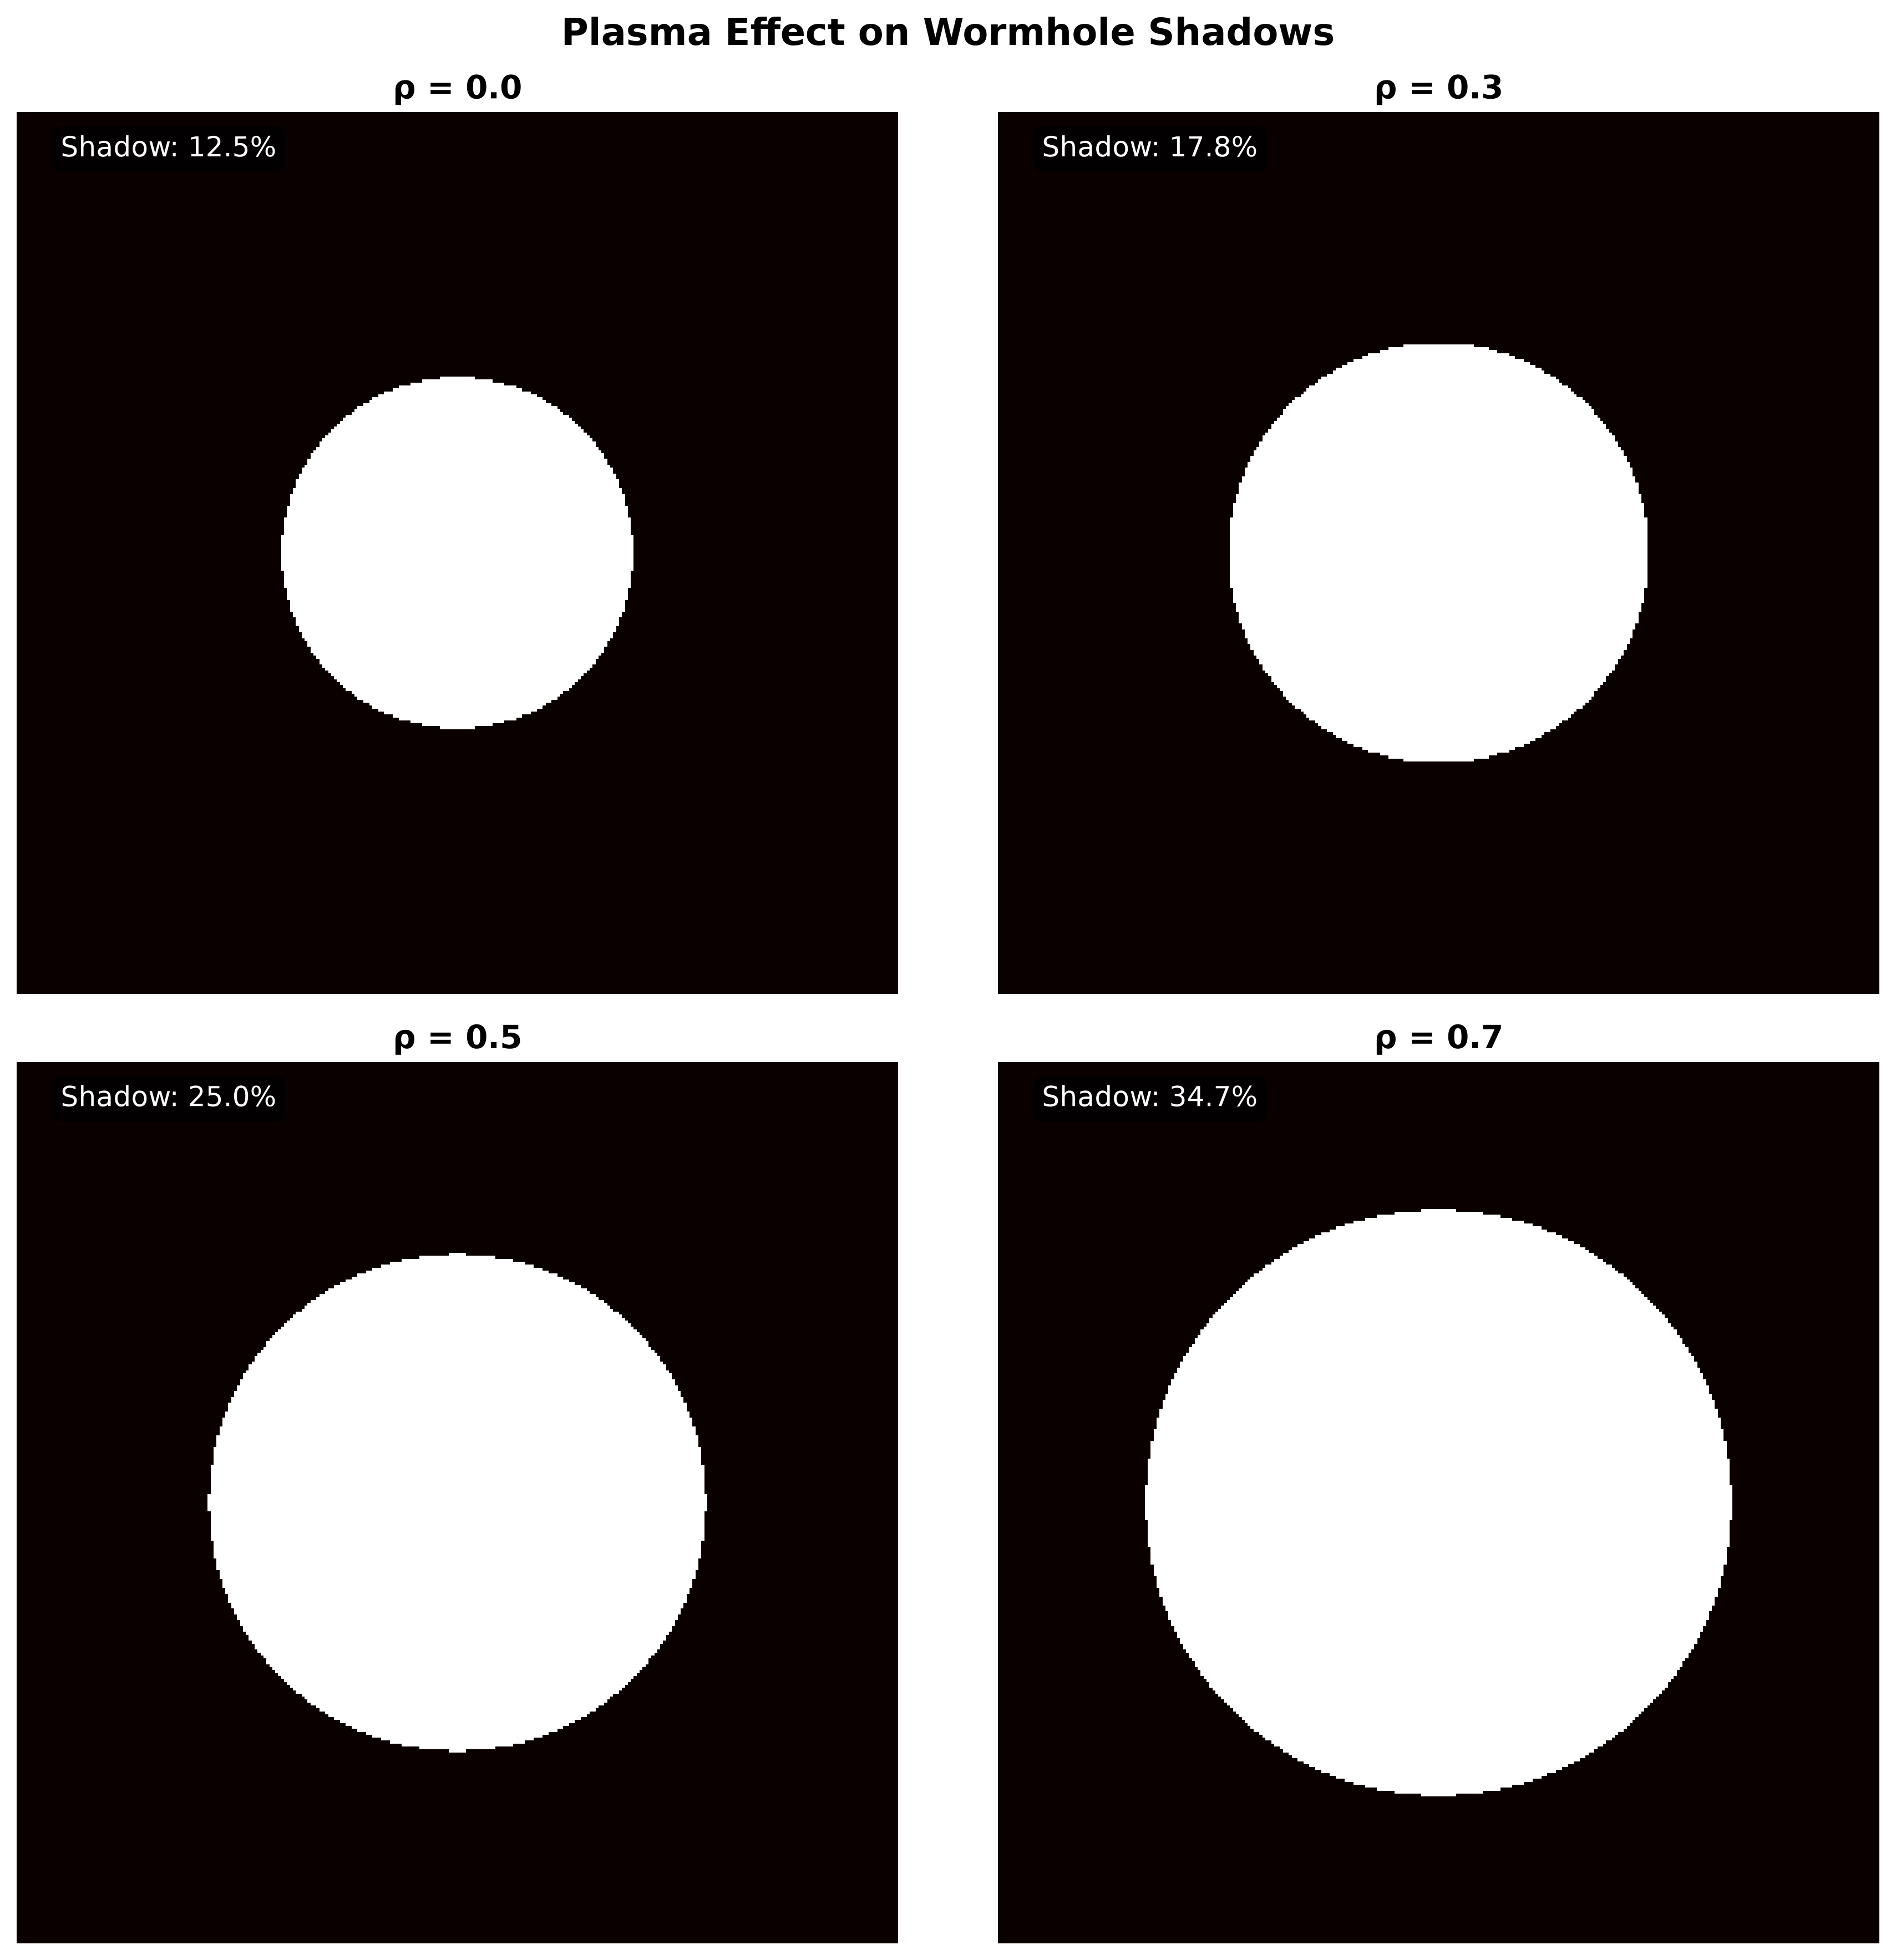

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i, (img, label) in enumerate(zip(shadow_images, labels)):
    ax = axes[i]
    
    # Show as white shadow on black (EHT style)
    ax.imshow(1 - img, cmap='hot', origin='lower', vmin=0, vmax=1)
    ax.set_title(label, fontsize=14, fontweight='bold')
    ax.axis('off')
    
    dark_pixels = np.sum(img == 0)
    total_pixels = img.size
    frac = dark_pixels / total_pixels * 100
    ax.text(0.05, 0.95, f'Shadow: {frac:.1f}%', 
            transform=ax.transAxes, fontsize=12, color='white',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

plt.suptitle('Plasma Effect on Wormhole Shadows', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/shadows/plasma/plasma_shadows_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [37]:

print("Shadow images debug:")
print("=" * 50)
for i, (img, label) in enumerate(zip(shadow_images, labels)):
    dark = np.sum(img == 0)
    bright = np.sum(img == 1)
    total = img.size
    print(f"{label}: dark={dark}, bright={bright}, total={total}")
    print(f"  Unique values: {np.unique(img)}")
print("=" * 50)

Shadow images debug:
ρ = 0.0: dark=11248, bright=78752, total=90000
  Unique values: [0. 1.]
ρ = 0.3: dark=16044, bright=73956, total=90000
  Unique values: [0. 1.]
ρ = 0.5: dark=22472, bright=67528, total=90000
  Unique values: [0. 1.]
ρ = 0.7: dark=31224, bright=58776, total=90000
  Unique values: [0. 1.]
